# Student Performance Indicator

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


#### Import the CSV Data as Pandas DataFrame

In [5]:
df = pd.read_csv('StudentsPerformance.csv')

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [7]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [8]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

#### There are no missing values in the data set

### 3.3 Check data types

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 Check statistics of data set

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring Data

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
print("Categories in 'gender' variable:     ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable:     ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable:     ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:     ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ", end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable:      <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable:      <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [16]:
# define numerical & categorical columns

numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'int64']
# print(categorical_features)
#print columns

print('We have {} numerical features : {}'.format(len(numerical_features), numerical_features))
print('We have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']
We have 3 categorical features : ['math score', 'reading score', 'writing score']


In [17]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


## Adding the 'Total score' and 'Average Column'

In [20]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score'] 
df['average'] = df['total_score']/3

## Identifying the number of students with full marks in each subject

In [35]:
df[df['reading score'] == 100]['average'].count()
# count() function tells you that how many non-null values are present in each column.

np.int64(17)

In [47]:
reading_full = (df['reading score'] == 100).sum()
writing_full = (df['writing score'] == 100).sum()
math_full = (df['math score'] == 100).sum()

reading_full,writing_full,math_full


print(f"Number of students with full marks in Maths : {math_full}")
print(f"Number of students with full marks in Writing : {writing_full}")
print(f"Number of students with full marks in Reading : {reading_full}")

Number of students with full marks in Maths : 7
Number of students with full marks in Writing : 14
Number of students with full marks in Reading : 17


### Insights
- Students have performed worst in Math and best performed in reading.

# Exploring Data (Vizualization)

### Vizualizing average score distribution to make some conculsion

- Histogram
- Kernel Density Function (KDE)

<Axes: xlabel='average', ylabel='Count'>

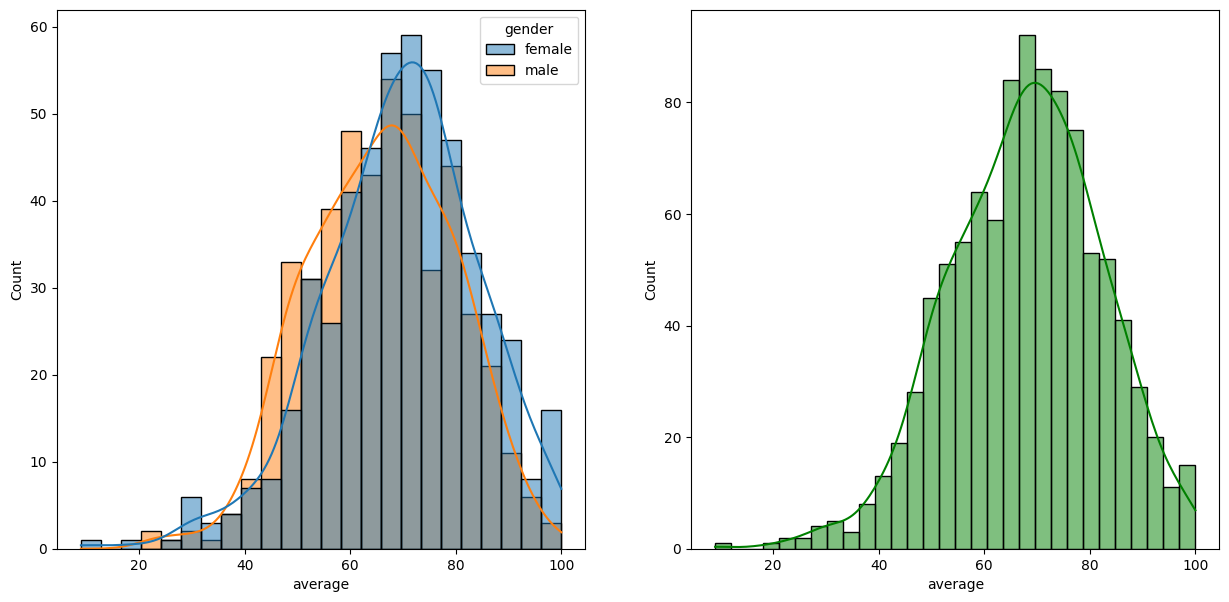

In [79]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,2)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(1,2,1)
sns.histplot(data=df,x='average',kde=True,hue='gender')

<Axes: xlabel='total_score', ylabel='Count'>

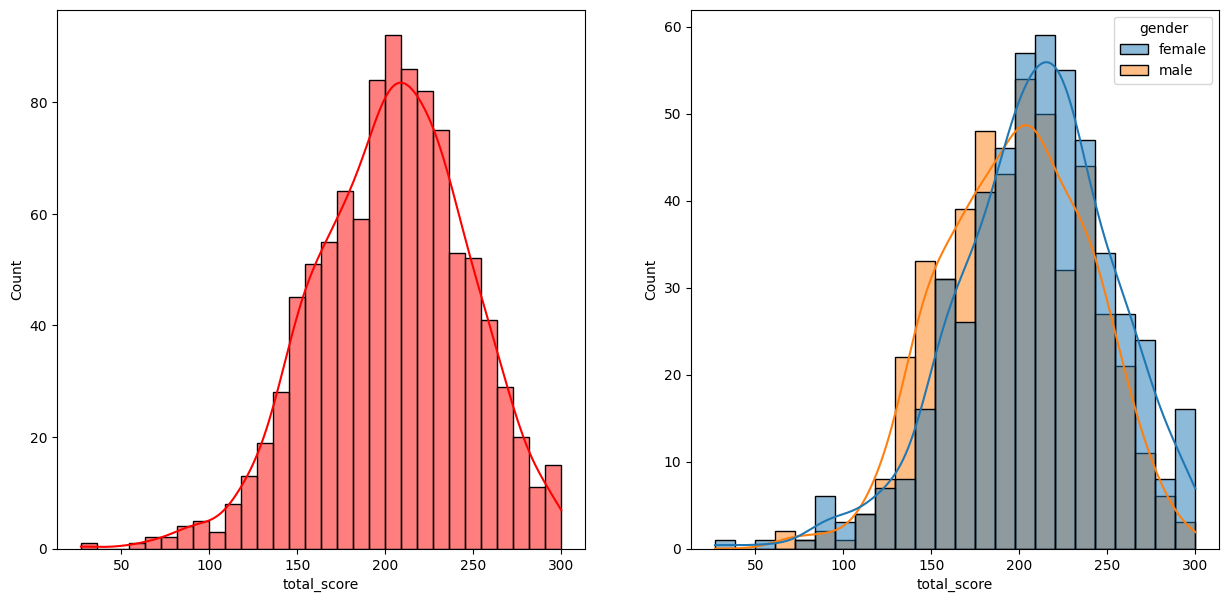

In [83]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='total_score',kde=True,bins=30,color='red')
plt.subplot(1,2,2)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')

### Insights
- female students performed well then male students

<Axes: xlabel='average', ylabel='Count'>

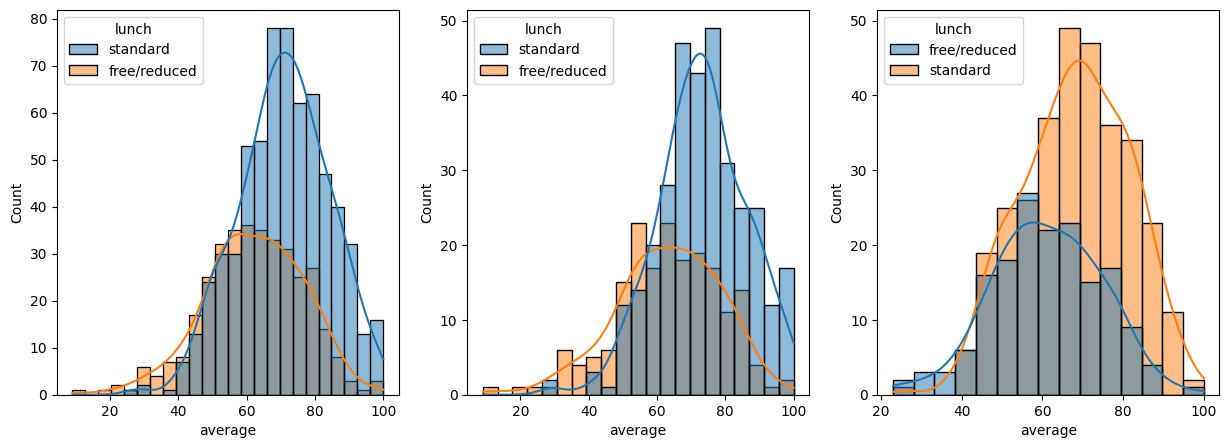

In [92]:
fig,axs = plt.subplots(1,3,figsize=(15,5))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average',kde=True,hue="lunch")
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='female'], x='average', kde=True,hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='male'],x='average',kde=True,hue='lunch')

In [109]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

### Insights
- Students having standard lunch performed well in exams regardless of gender.

In [107]:
df[(df['gender'] == 'female') & ((df['parental level of education'] == "bachelor's degree") | (df['parental level of education'] == "some highschool")) ]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
27,female,group C,bachelor's degree,standard,none,67,69,75,211,70.333333
90,female,group C,bachelor's degree,standard,none,65,72,74,211,70.333333
99,female,group D,bachelor's degree,standard,none,65,67,62,194,64.666667
114,female,group E,bachelor's degree,standard,completed,99,100,100,299,99.666667
...,...,...,...,...,...,...,...,...,...,...
912,female,group C,bachelor's degree,standard,completed,52,61,66,179,59.666667
913,female,group C,bachelor's degree,free/reduced,completed,47,62,66,175,58.333333
969,female,group B,bachelor's degree,standard,none,75,84,80,239,79.666667
970,female,group D,bachelor's degree,standard,none,89,100,100,289,96.333333


<Axes: xlabel='average', ylabel='Count'>

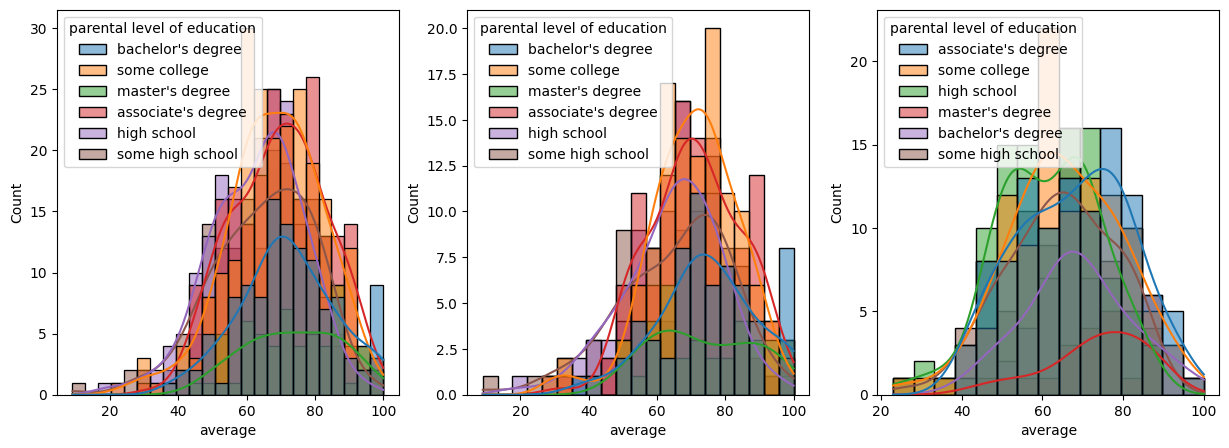

In [113]:
fig,axs = plt.subplots(1,3,figsize=(15,5))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average',kde=True,hue="parental level of education")
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='female'], x='average',kde=True,hue="parental level of education")
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='male'],x='average',kde=True,hue='parental level of education')

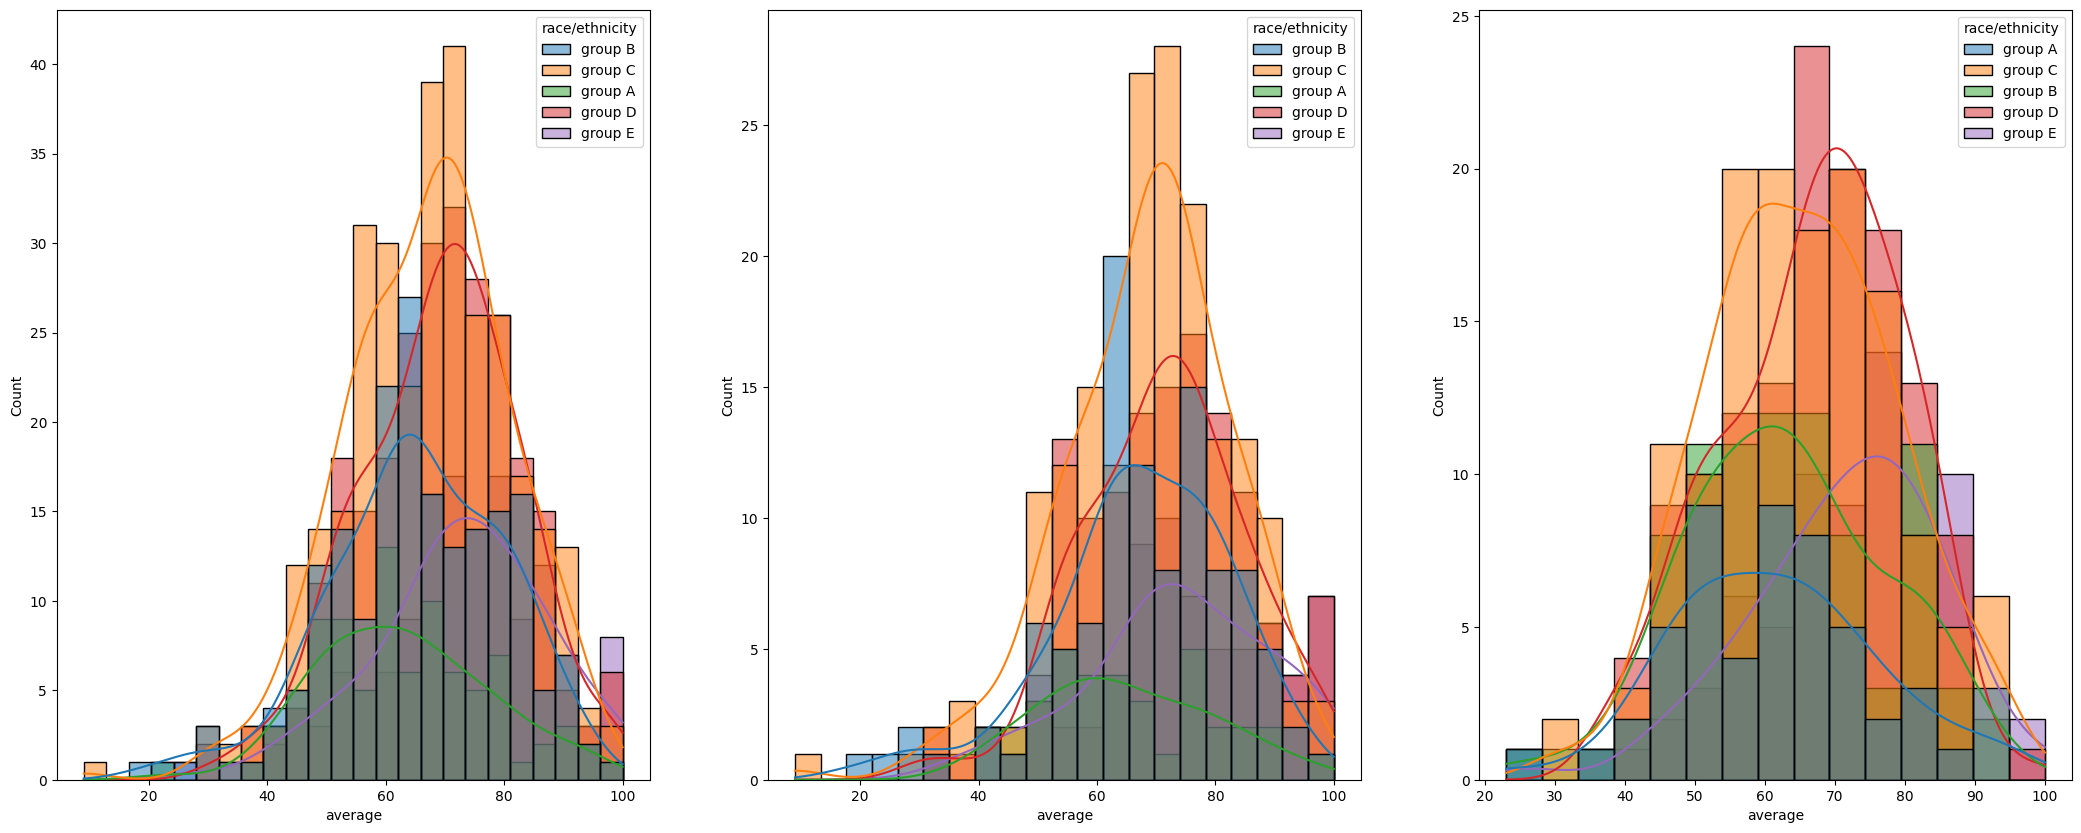

In [118]:
plt.subplots(1,3,figsize=(26,10))
plt.subplot(131)
ax =sns.histplot(data=df,x='average',kde=True,hue='race/ethnicity')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

### Maximum score of students in all three subject

<Axes: title={'center': 'WRITING SCORES'}, ylabel='writing score'>

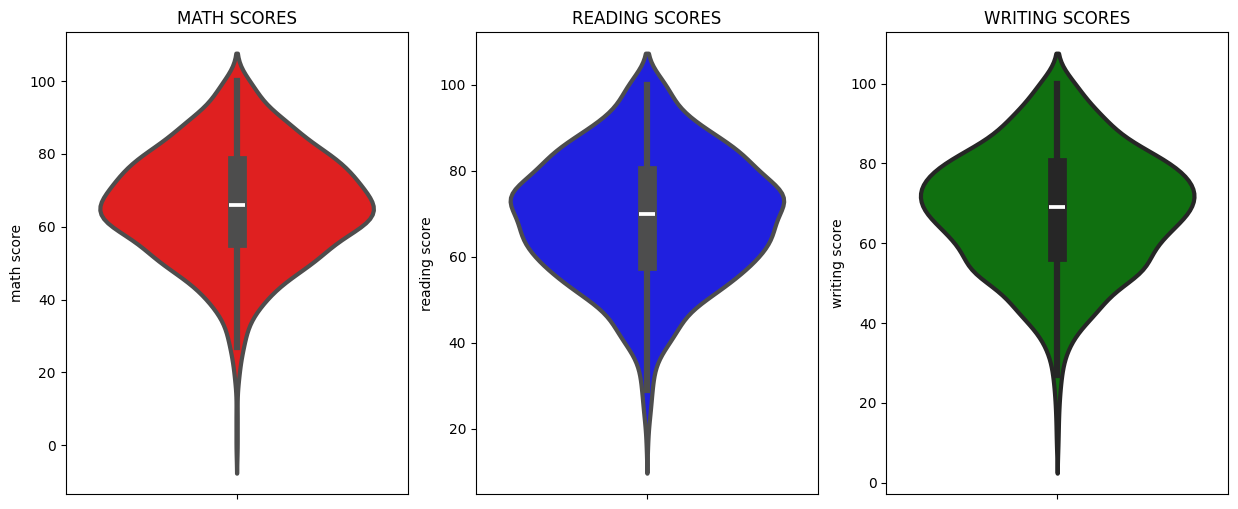

In [172]:
fig, axs = plt.subplots(1,3,figsize=(15,6))
plt.subplot(131)
plt.title('MATH SCORES')
sns.violinplot(y='math score', data=df,color='red',linewidth=3)
plt.subplot(132)
plt.title('READING SCORES')
sns.violinplot(y='reading score', data=df,color='blue',linewidth=3)
plt.subplot(133)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score', data=df,color='g',linewidth=3)

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

## UNIVARIATE ANALYSIS USING PIEPLOT

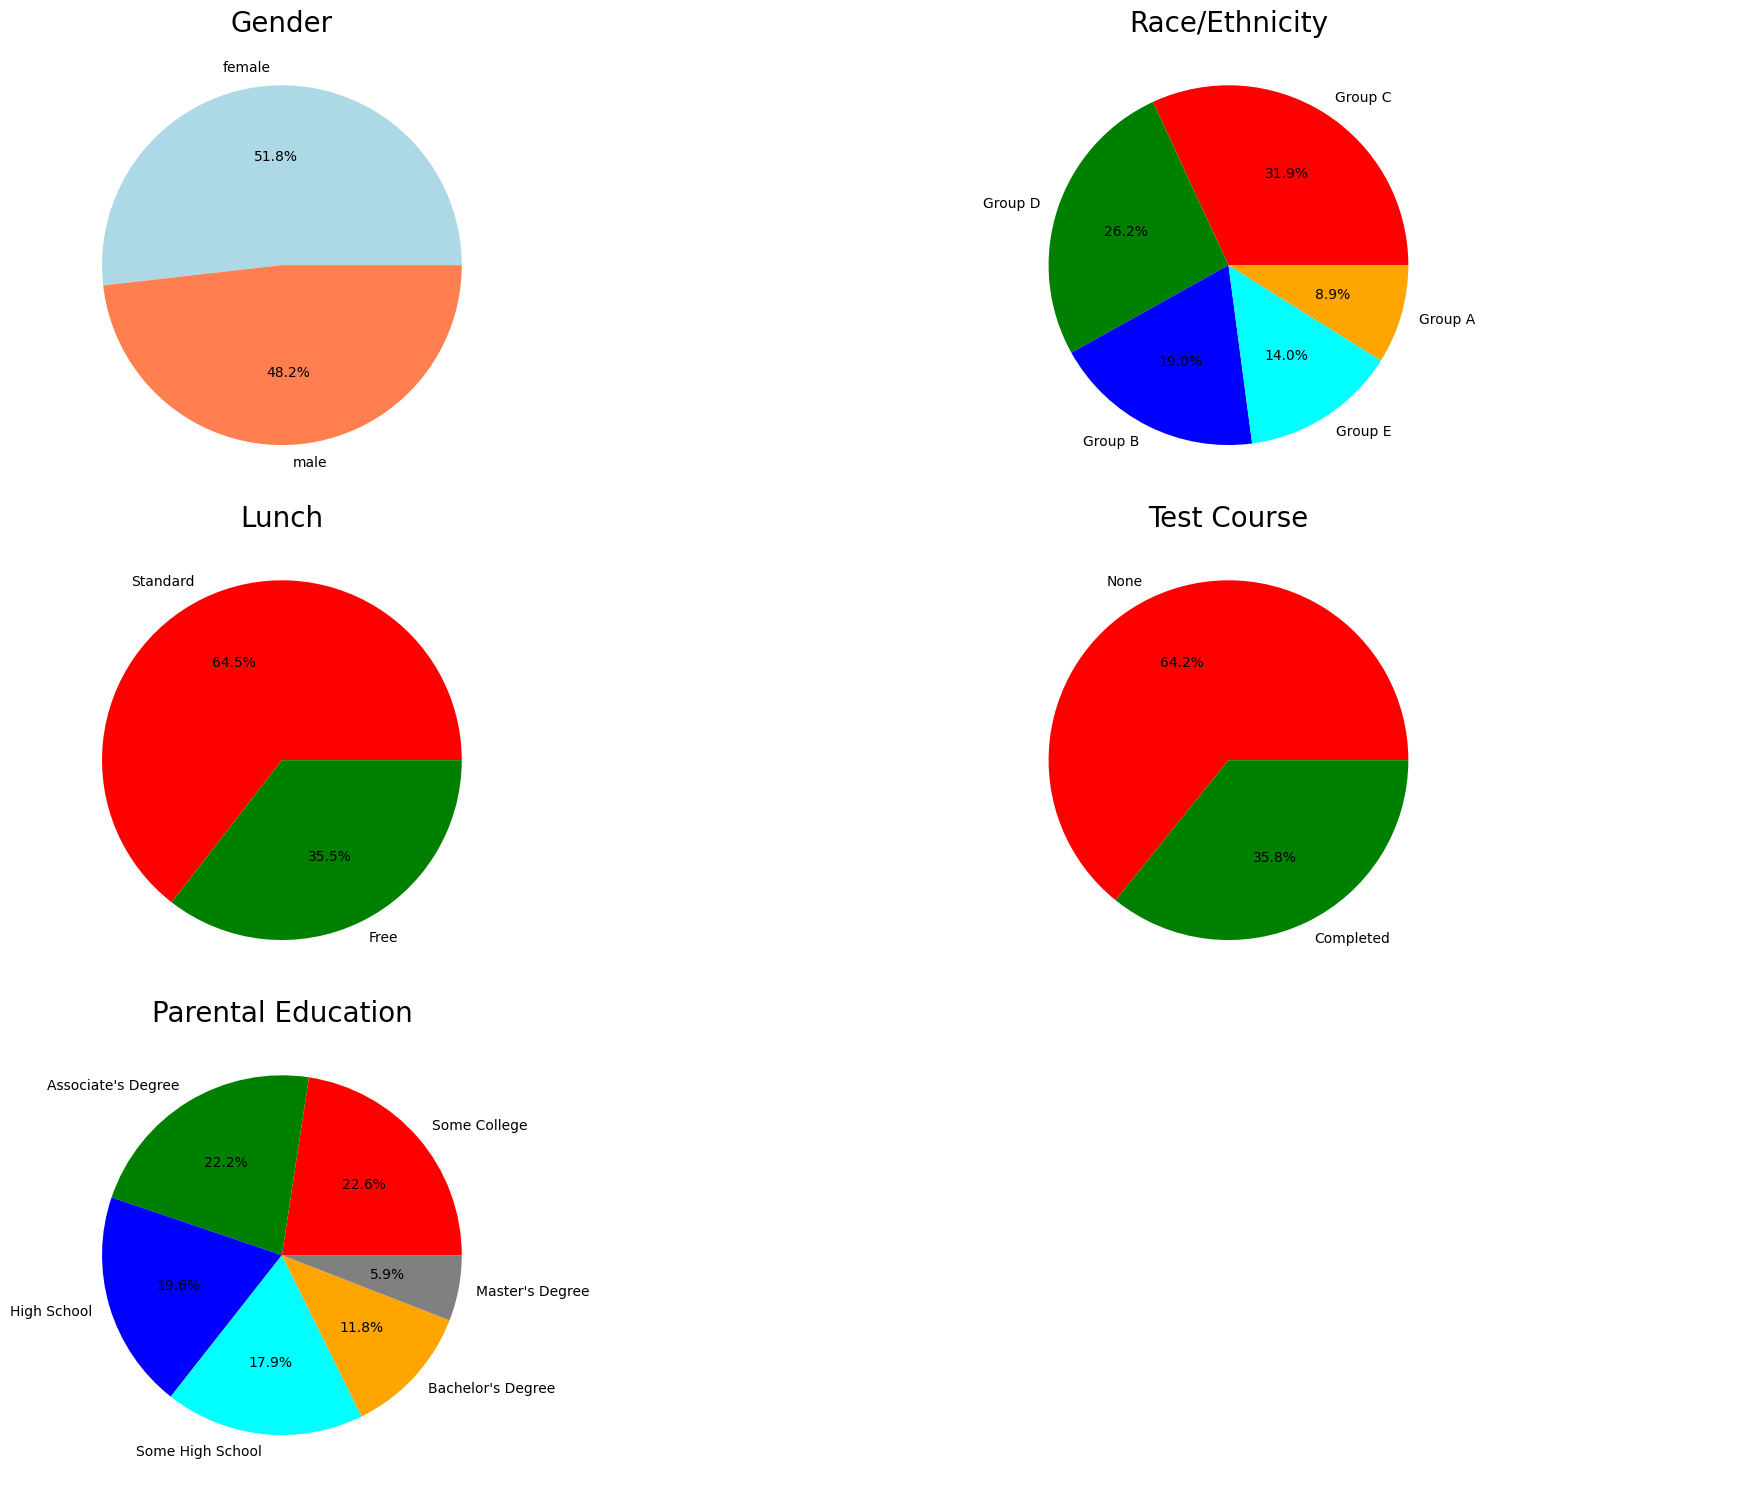

In [179]:
# There are two main things in pie chart, size and labels

# Genders
fig,axs = plt.subplots(3,2,figsize=(20,15))
size = df['gender'].value_counts()
labels = df['gender'].unique()
colors = ['lightblue','coral']
axs[0,0].pie(size,labels=labels,colors=colors,autopct='%1.1f%%')
axs[0,0].set_title('Gender', fontsize=20)


# Race/Ethnicity

size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

axs[0,1].pie(size, colors = color,labels = labels,autopct = '%1.1f%%')
axs[0,1].set_title('Race/Ethnicity', fontsize = 20)

# Lunch

size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

axs[1,0].pie(size, colors = color,labels = labels,autopct = '%1.1f%%')
axs[1,0].set_title('Lunch', fontsize = 20)


#Test Prep Course

size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

axs[1,1].pie(size, colors = color,labels = labels,autopct = '%1.1f%%')
axs[1,1].set_title('Test Course', fontsize = 20)


# Parental Level of education

size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

axs[2,0].pie(size, colors = color,labels = labels,autopct = '%1.1f%%')
axs[2,0].set_title('Parental Education', fontsize = 20)

axs[2,1].axis('off')
plt.tight_layout()





#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

### Feature wise Vizualization

How each feature is affecting the scores

#### GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

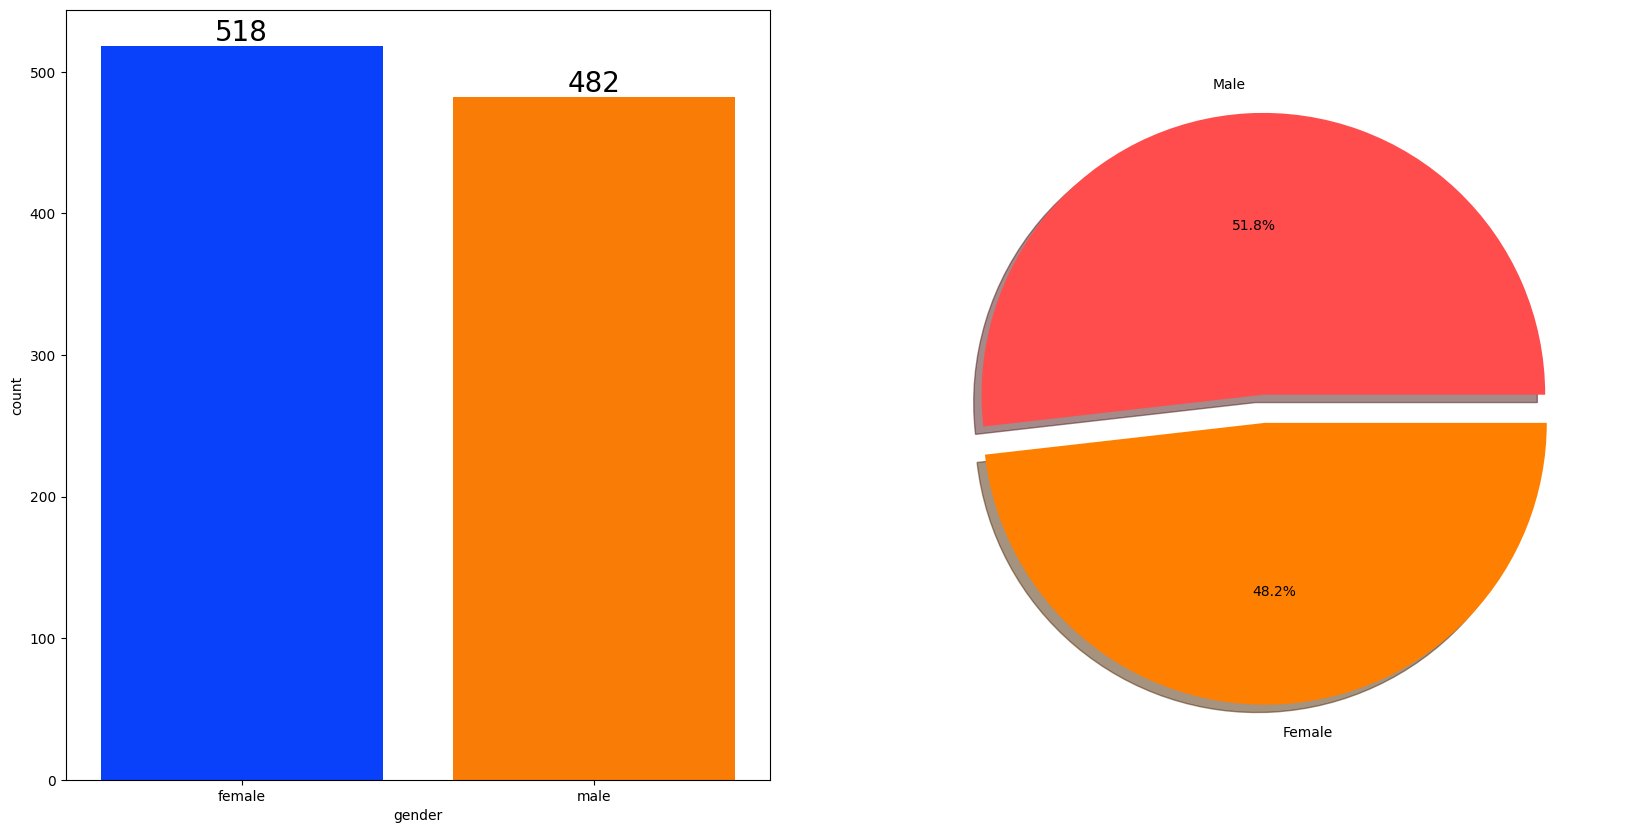

In [182]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [205]:
gender_group = df.groupby('gender')[['math score', 'reading score', 'writing score','average']].mean()
gender_group

,math score,reading score,writing score,average
gender,,,,
female,63.633205,72.608108,72.467181,69.569498
male,68.728216,65.473029,63.311203,65.837483


In [209]:
[gender_group['average'].iloc[0],gender_group['math score'].iloc[0]]

[np.float64(69.56949806949807), np.float64(63.633204633204635)]

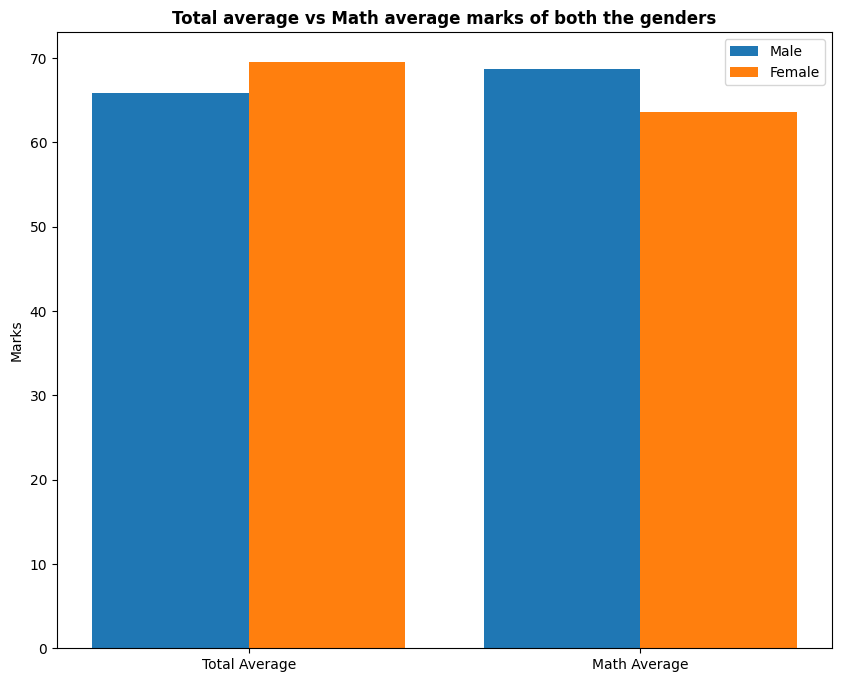

In [212]:
plt.figure(figsize=(10,8))

X = ['Total Average', 'Math Average']

female_score = [gender_group['average'].iloc[0],gender_group['math score'].iloc[0]]
male_score = [gender_group['average'].iloc[1],gender_group['math score'].iloc[1]]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_score, 0.4, label = "Male")
plt.bar(X_axis + 0.2, female_score, 0.4, label = "Female")

plt.xticks(X_axis,X)
plt.ylabel("Marks")
plt.title("Total average vs Math average marks of both the genders", fontweight = 'bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

([<matplotlib.patches.Wedge at 0x160387230>,
 [Text(0.7538673497905694, 1.1796965791760794, 'group C'),
  Text(-1.2363734549023893, 0.4017221427961491, 'group D'),
  Text(-0.5828982762888565, -1.1619938035546833, 'group B'),
  Text(0.703457478350195, -1.0932280531312693, 'group E'),
  Text(1.2495150017699597, -0.3587649095881841, 'group A')],
 [Text(0.3769336748952847, 0.5898482895880396, '31.9%'),
  Text(-0.5706339022626412, 0.1854102197520688, '26.2%'),
  Text(-0.2690299736717799, -0.5363048324098538, '19.0%'),
  Text(0.3246726823154746, -0.5045667937528934, '14.0%'),
  Text(0.5766992315861351, -0.16558380442531573, '8.9%')])

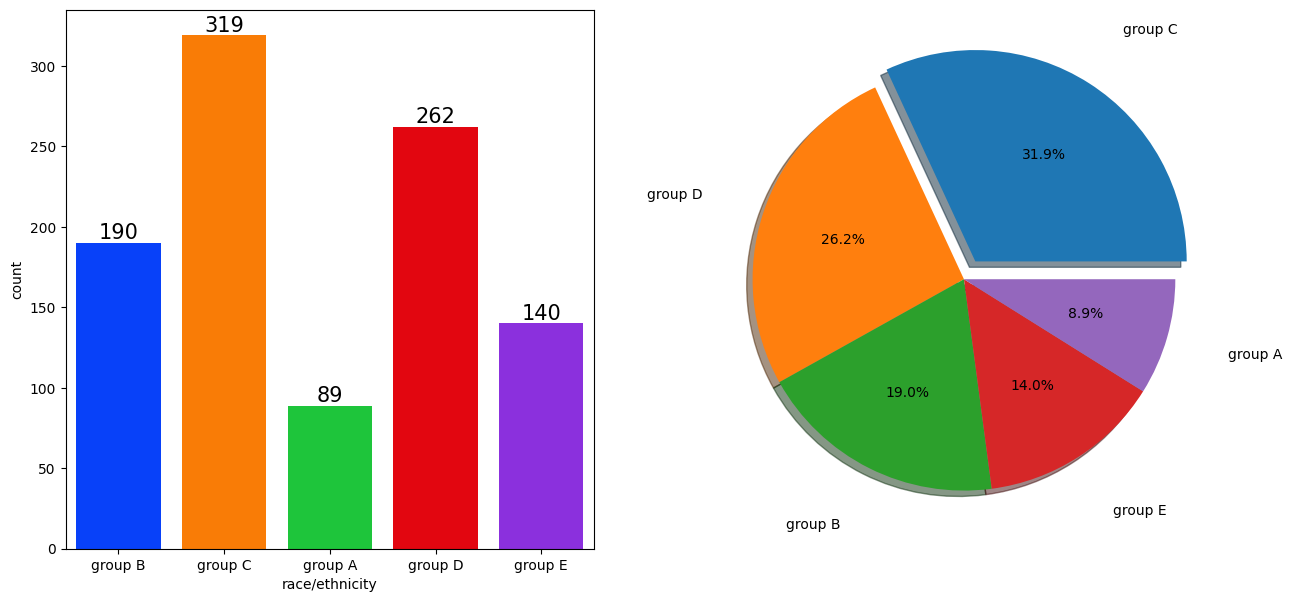

In [256]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
sns.countplot(data=df, x=df['race/ethnicity'], palette='bright', saturation=0.95,ax=axs[0])
for container in axs[0].containers:
    axs[0].bar_label(container, color='black',size=15)
# Size and labels
size = df['race/ethnicity'].value_counts()
labels = ['group C', 'group D', 'group B', 'group E', 'group A']
axs[1].pie(x=size,labels=labels,autopct="%1.1f%%", explode=[0.1,0,0,0,0],shadow=True, labeldistance=1.3)

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

In [265]:
group_data = df.groupby('race/ethnicity')['math score'].mean()
group_data

race/ethnicity
group A    61.629213
group B    63.452632
group C    64.463950
group D    67.362595
group E    73.821429
Name: math score, dtype: float64

In [269]:
Group_data2 = df.groupby('race/ethnicity')
Group_data2['math score'].mean().values

array([61.62921348, 63.45263158, 64.46394984, 67.36259542, 73.82142857])

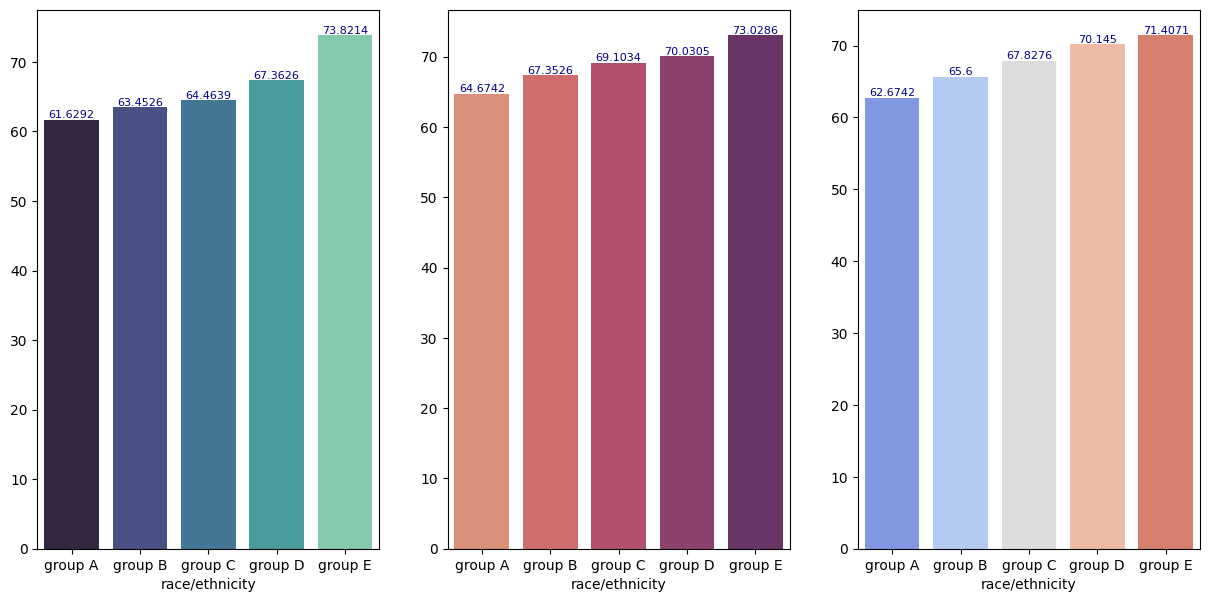

In [284]:
Group_data2 = df.groupby('race/ethnicity')
fig, axs = plt.subplots(1,3,figsize=(15,7))
sns.barplot(x = Group_data2['math score'].mean().index, y = Group_data2['math score'].mean().values,ax=axs[0], palette='mako')
for container in axs[0].containers:
    axs[0].bar_label(container, color='darkblue',size=8)

sns.barplot(x = Group_data2['reading score'].mean().index, y = Group_data2['reading score'].mean().values,ax=axs[1], palette='flare')
for container in axs[1].containers:
    axs[1].bar_label(container, color='darkblue',size=8)

sns.barplot(x = Group_data2['writing score'].mean().index, y = Group_data2['writing score'].mean().values,ax=axs[2], palette='coolwarm')
for container in axs[2].containers:
    axs[2].bar_label(container, color='darkblue',size=8)



#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

Text(0, 0.5, 'Count')

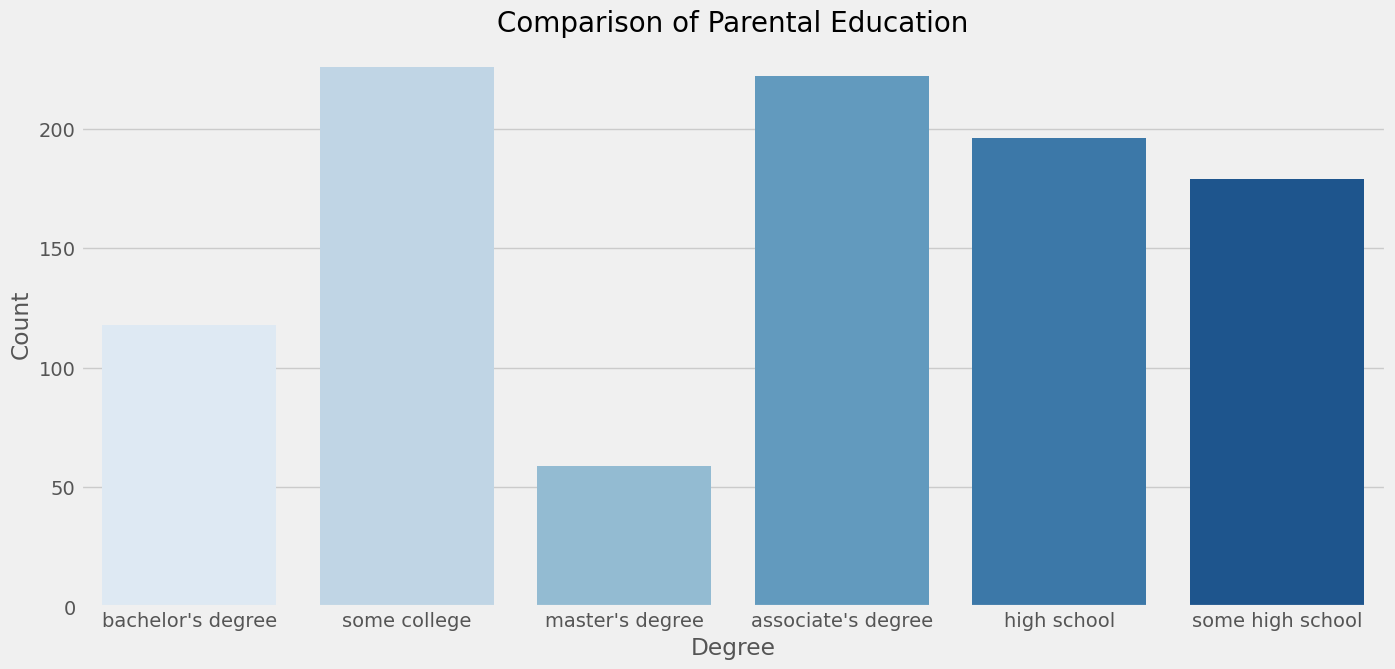

In [299]:
plt.figure(figsize=(15,7))
plt.style.use('fivethirtyeight')
sns.countplot(x =df['parental level of education'],palette='Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize=20)
plt.xlabel('Degree')
plt.ylabel('Count')

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

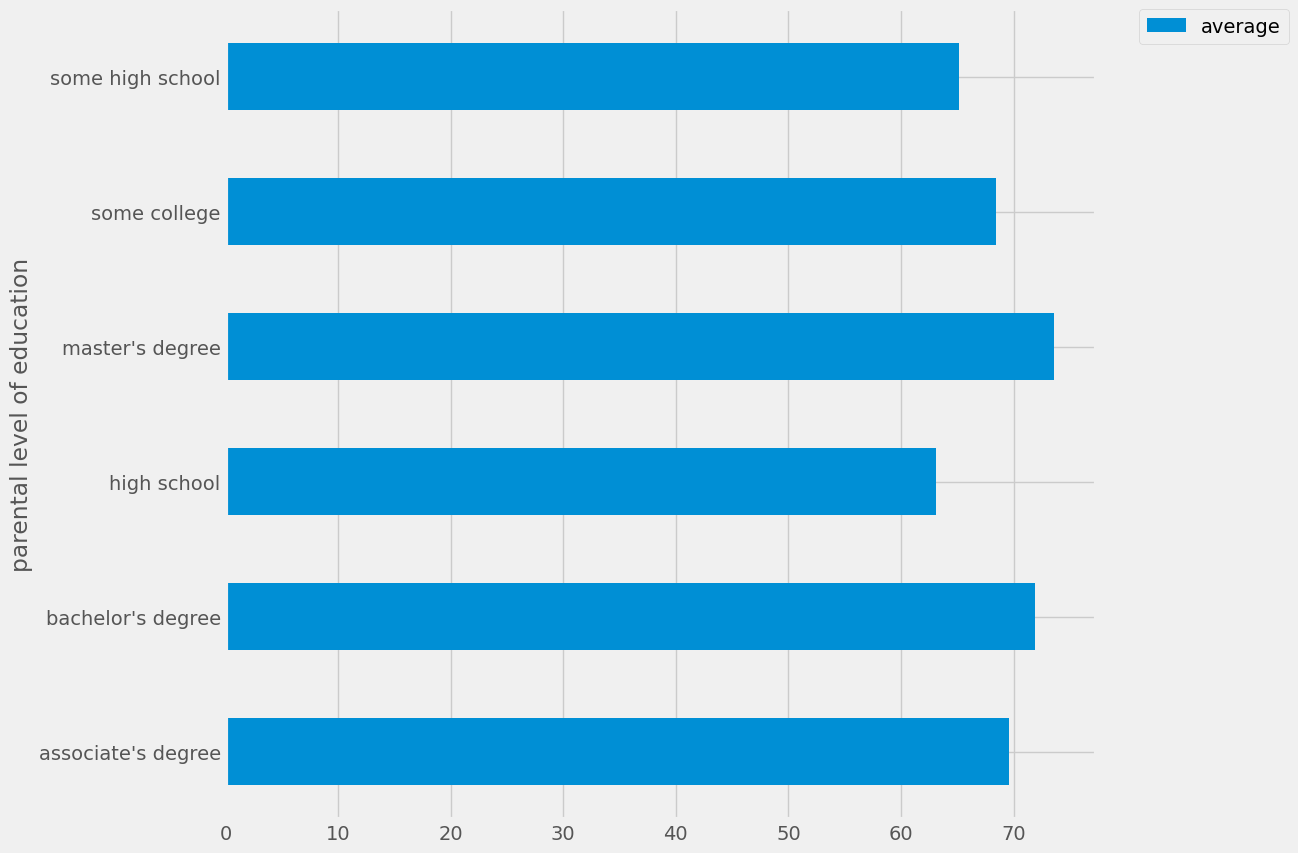

In [313]:
df.groupby('parental level of education')['average'].agg('mean').plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

<Axes: title={'center': 'Comparison of different types of lunch'}, xlabel='lunch', ylabel='count'>

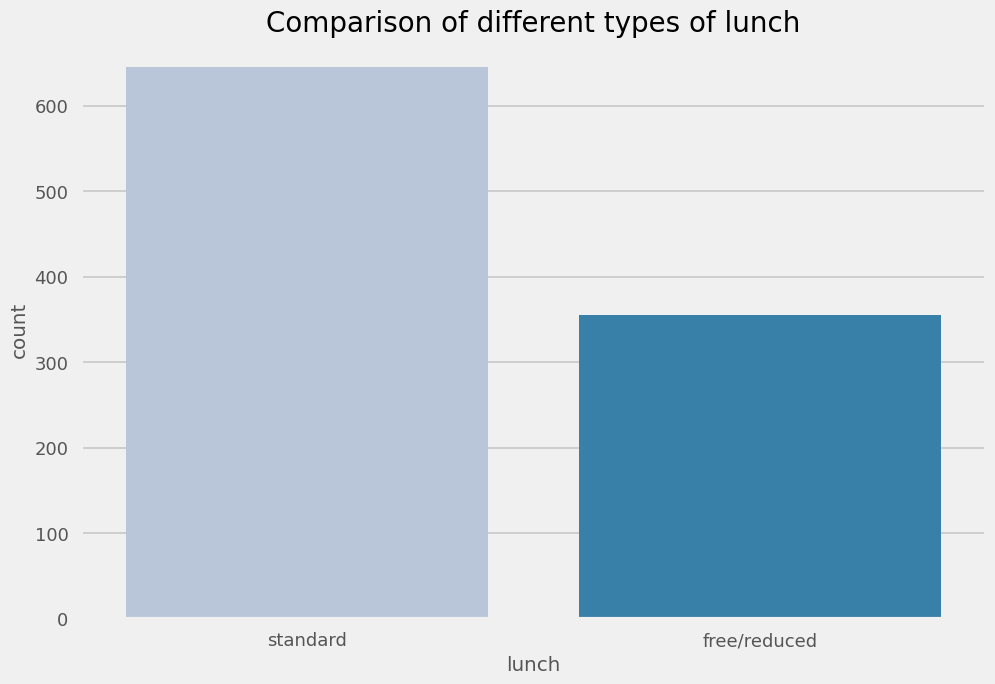

In [324]:

plt.style.use('seaborn-v0_8-talk')
plt.title('Comparison of different types of lunch', fontweight = 20, fontsize=20)
sns.countplot(x = df['lunch'], palette='PuBu')

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

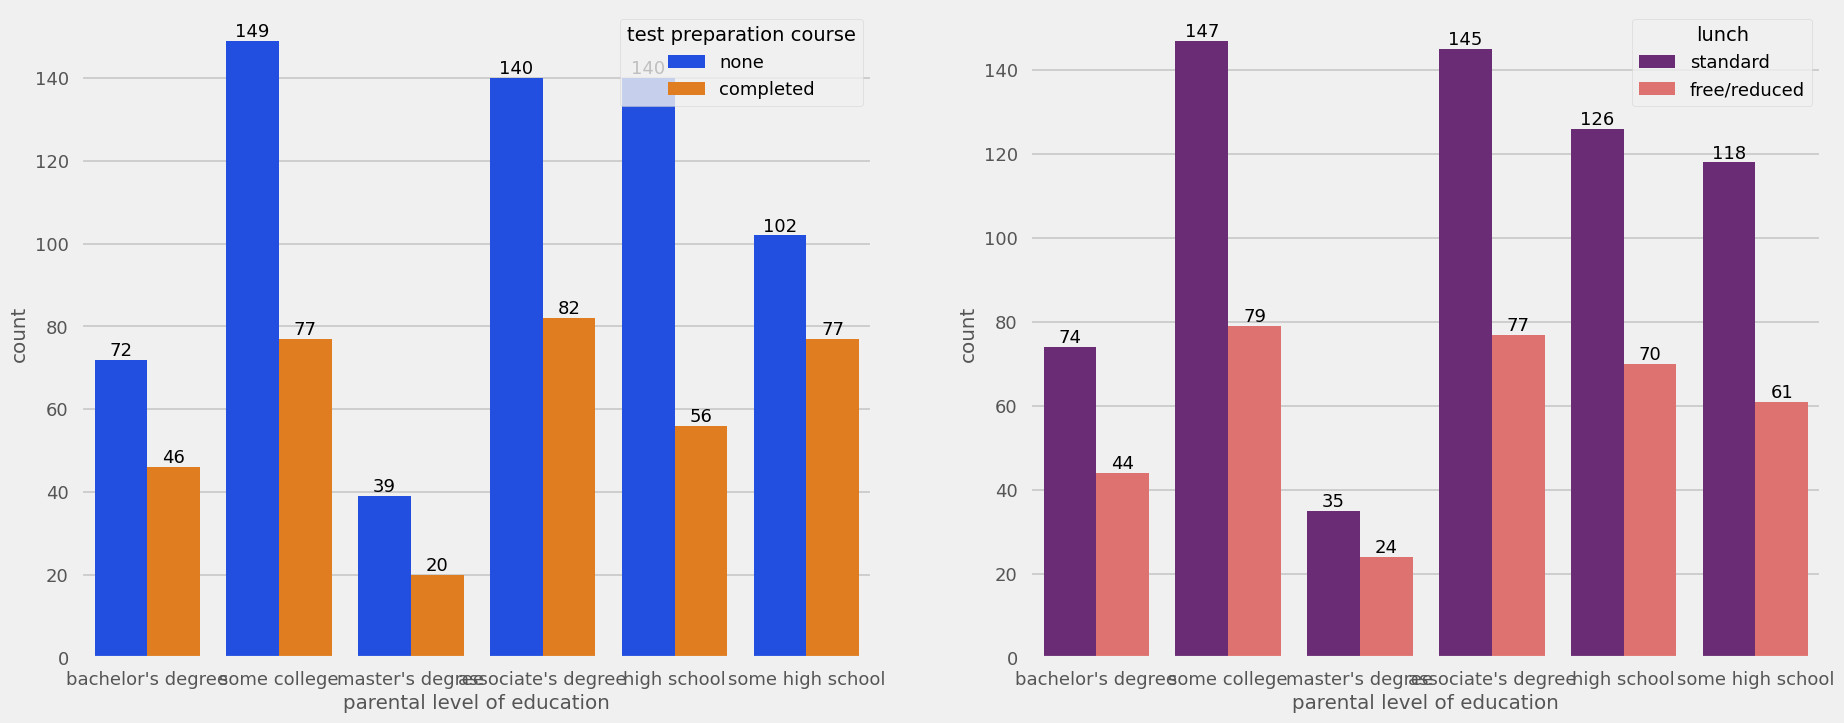

In [336]:
fig, axs = plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'], data=df,palette='bright', hue='test preparation course',ax=axs[0])
for container in axs[0].containers:
    axs[0].bar_label(container,size=13, color='black')

sns.countplot(x=df['parental level of education'], data=df,palette='magma', hue='lunch',ax=axs[1])
for container in axs[1].containers:
    axs[1].bar_label(container,size=13, color='black')

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

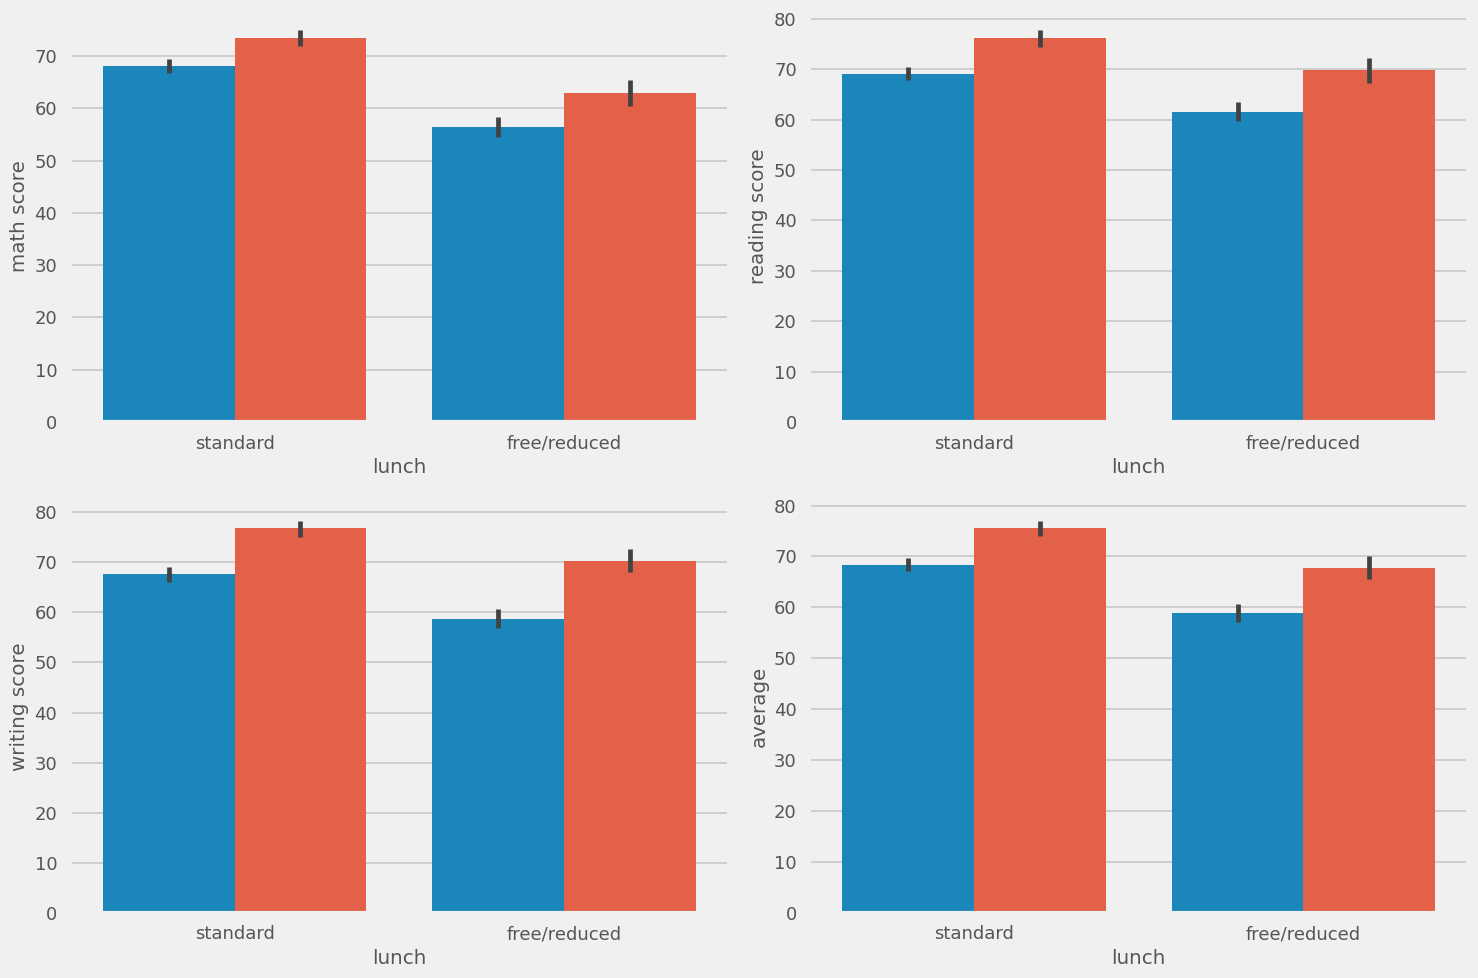

In [353]:
plt.figure(figsize=(15,10))


plt.subplot(2,2,1)
sns.barplot(x=df['lunch'], y = df['math score'], hue=df['test preparation course'], legend=None)

plt.subplot(2,2,2)
sns.barplot(x=df['lunch'], y = df['reading score'], hue=df['test preparation course'], legend=None)

plt.subplot(2,2,3)
sns.barplot(x=df['lunch'], y = df['writing score'], hue=df['test preparation course'], legend=None)

plt.subplot(2,2,4)
sns.barplot(x=df['lunch'], y = df['average'], hue=df['test preparation course'], legend=None)

plt.tight_layout()


#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

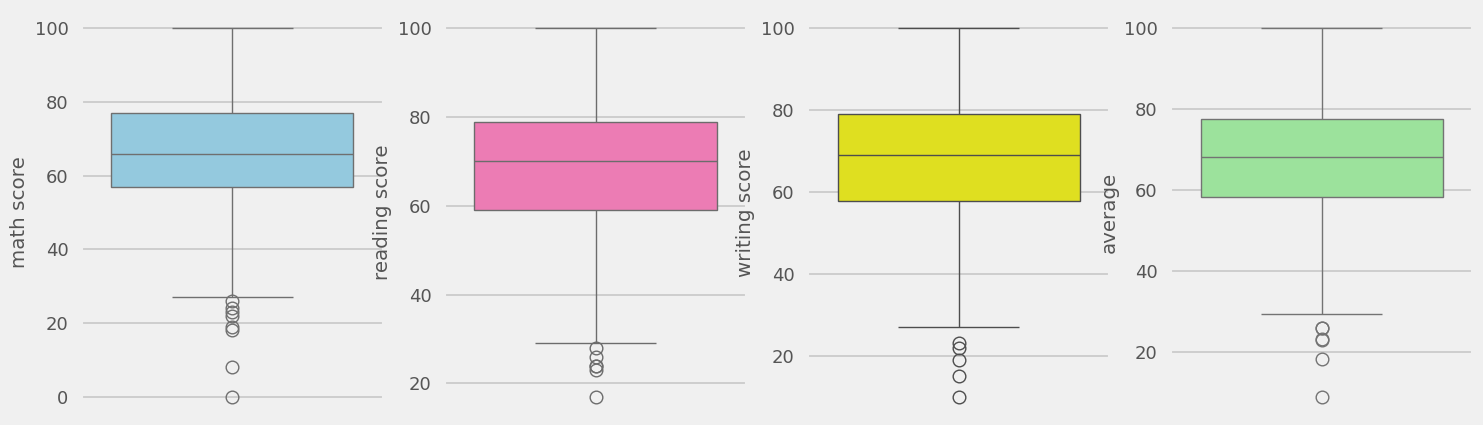

In [354]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

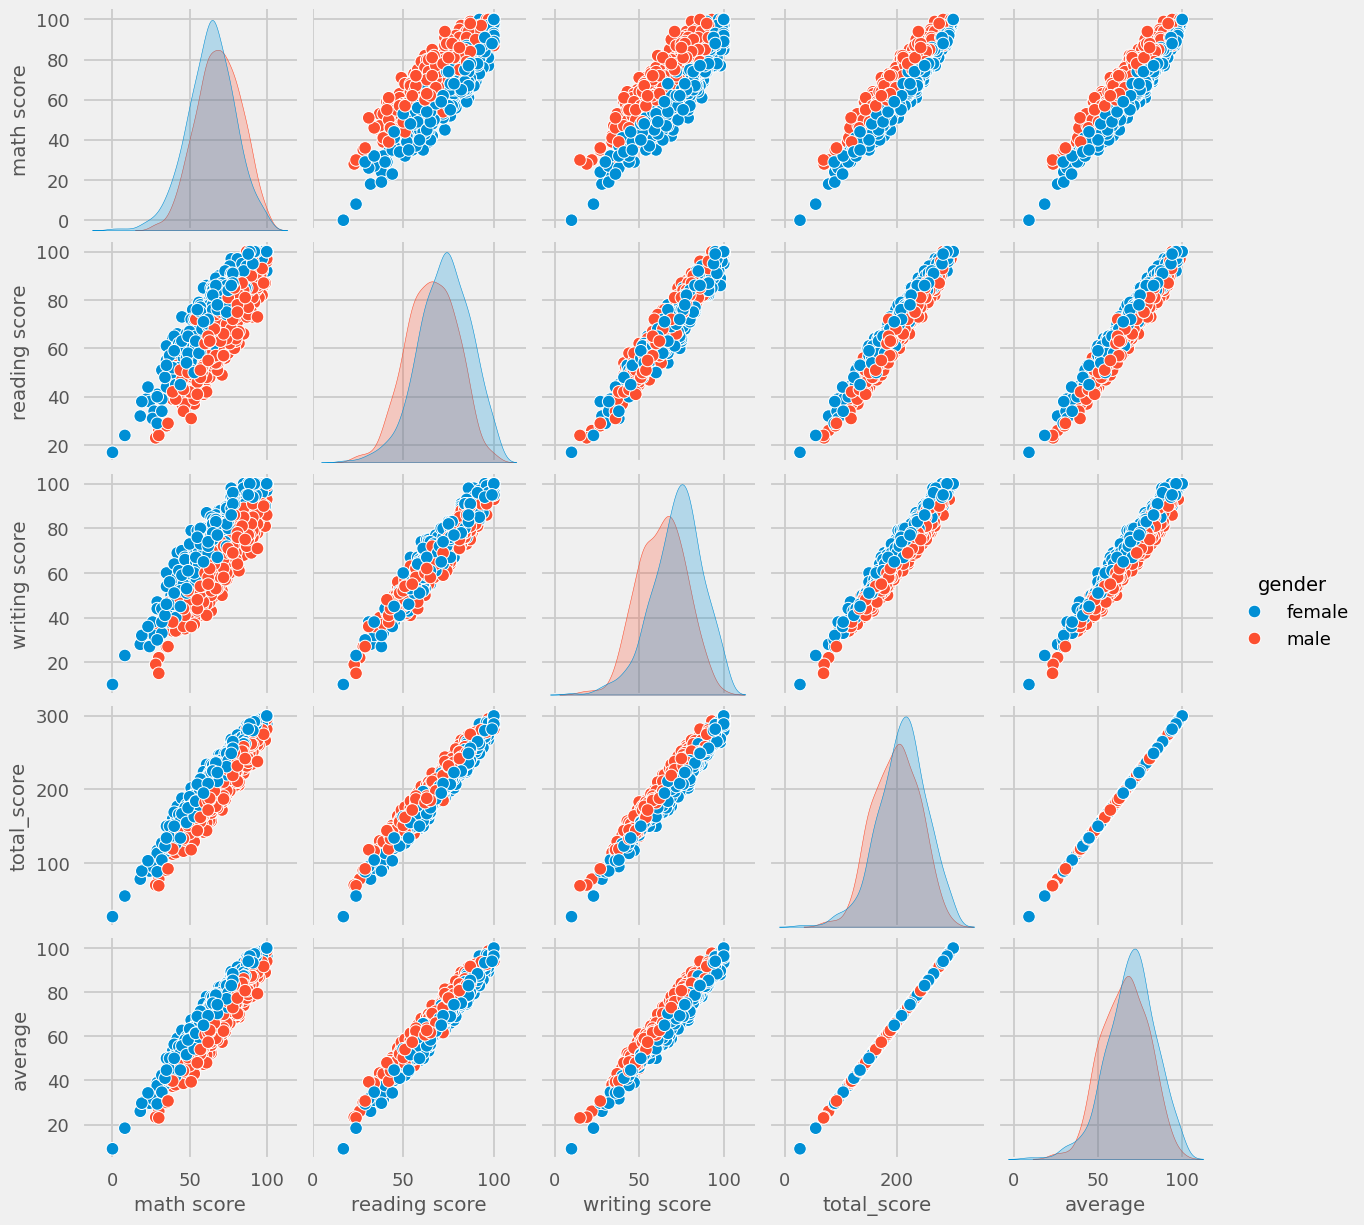

In [355]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.